# Experiment 4.4.1 — Stage-2 Memory Architecture Sweep

Analysis-only notebook for the finalized `tau_mem × recurrence` sweep.

Primary architecture metric: **Stage-2 endpoint membrane (`Uend`) + train-only scaled Linear probe BA**.

Secondary metrics:
- Hidden WholeCount + Linear BA
- Output WholeCount BA
- `Uend - HiddenCount` and `Uend - OutputCount` gaps
- firing rate and post-end tail activity
- paired `RSNN - FF` effect at each Stage-2 time constant


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "AGENTS.md").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root")

REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / "notebooks" / "artifacts" / "experiment_4_4_1_stage2_memory_sweep" / "stage2_tau_x_recurrence_v1"
FILES = {
    "runs": ROOT / "runs.csv",
    "summary": ROOT / "summary.csv",
    "paired": ROOT / "paired_effects.csv",
    "paired_summary": ROOT / "paired_effects_summary.csv",
    "manifest": ROOT / "manifest.json",
}
missing = [str(path) for path in FILES.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing finalized Exp4.4.1 artifacts:\n" + "\n".join(missing))

runs = pd.read_csv(FILES["runs"])
summary = pd.read_csv(FILES["summary"])
paired = pd.read_csv(FILES["paired"])
paired_summary = pd.read_csv(FILES["paired_summary"])
manifest = json.loads(FILES["manifest"].read_text())
display(manifest)


{'experiment_id': 'experiment_4_4_1_stage2_memory_sweep',
 'files': {'paired_effects': 'paired_effects.csv',
  'paired_effects_summary': 'paired_effects_summary.csv',
  'runs': 'runs.csv',
  'summary': 'summary.csv'},
 'fixed': {'hidden_cap': 31,
  'local_condition': 'shift34',
  'output_cap': 31,
  'output_tau_mem_ms': 250.0,
  'stage2_width': 128,
  'threshold': 0.5,
  'training_objective': 'valid normalized output WholeCount CE',
  'variant': 'multi_ho'},
 'model_kinds': ['ff', 'rsnn'],
 'primary_architecture_metric': 'Uend + train-only scaled Linear probe balanced accuracy',
 'protocol_version': 'stage2_tau_x_recurrence_v1',
 'question': 'With Local128 fixed, how do passive Stage-2 tau_mem and dense recurrence interact to determine gesture-level memory quality and spike-accessible classification?',
 'run_count': 50,
 'secondary_metrics': ['Hidden WholeCount + train-only scaled Linear probe balanced accuracy',
  'Output WholeCount balanced accuracy',
  'Uend-HiddenCount gap',
  'Uen

## Protocol completeness


In [2]:
expected_taus = {125, 250, 500, 1000, 2000}
expected_models = {"ff", "rsnn"}
expected_seeds = {11, 23, 37, 53, 71}
assert set(manifest["tau_mem_ms"]) == expected_taus
assert set(manifest["model_kinds"]) == expected_models
assert set(manifest["seeds"]) == expected_seeds
assert manifest["run_count"] == 50
test = runs[runs["split"] == "test"].copy()
coverage = test.groupby(["model_kind", "tau_mem_ms"])["seed"].agg(lambda s: set(s))
for model in expected_models:
    for tau in expected_taus:
        assert coverage.loc[(model, tau)] == expected_seeds
print("Protocol coverage OK: 50 independent runs, 5 paired seeds per condition.")
display(test.head())


Protocol coverage OK: 50 independent runs, 5 paired seeds per condition.


,model_kind,tau_mem_ms,seed,split,output_whole_count_ba,hidden_whole_count_linear_ba,uend_linear_ba,uend_minus_hidden_count_ba,uend_minus_output_count_ba,state_events_per_neuron_second,output_events_per_neuron_second,state_tail_event_fraction,output_tail_event_fraction
0,ff,125,11,test,0.452942,0.563444,0.153901,-0.409543,-0.299041,54.184420,343.308062,0.0,0.000292
3,ff,125,23,test,0.503005,0.560736,0.191359,-0.369378,-0.311646,55.113201,378.617533,0.0,0.000642
6,ff,125,37,test,0.469565,0.554317,0.164016,-0.390301,-0.305549,50.429971,335.806241,0.0,0.000380
9,ff,125,53,test,0.471576,0.522548,0.143674,-0.378875,-0.327903,48.911641,331.009223,0.0,0.000208
12,ff,125,71,test,0.544626,0.537838,0.089455,-0.448383,-0.455171,59.200940,411.911336,0.0,0.000407


## Aggregate test metrics


In [3]:
cols = [
    "model_kind", "tau_mem_ms",
    "uend_linear_ba_mean", "uend_linear_ba_std",
    "hidden_whole_count_linear_ba_mean", "hidden_whole_count_linear_ba_std",
    "output_whole_count_ba_mean", "output_whole_count_ba_std",
    "uend_minus_hidden_count_ba_mean",
    "uend_minus_output_count_ba_mean",
]
display(summary[cols].sort_values(["model_kind", "tau_mem_ms"]))


,model_kind,tau_mem_ms,uend_linear_ba_mean,uend_linear_ba_std,hidden_whole_count_linear_ba_mean,hidden_whole_count_linear_ba_std,output_whole_count_ba_mean,output_whole_count_ba_std,uend_minus_hidden_count_ba_mean,uend_minus_output_count_ba_mean
0,ff,125,0.148481,0.037471,0.547777,0.017259,0.488343,0.036297,-0.399296,-0.339862
1,ff,250,0.178183,0.029920,0.516052,0.022842,0.472060,0.027412,-0.337869,-0.293877
2,ff,500,0.230609,0.017028,0.514900,0.016930,0.453153,0.021038,-0.284291,-0.222544
3,ff,1000,0.301051,0.034124,0.505189,0.032981,0.454484,0.028748,-0.204138,-0.153433
4,ff,2000,0.352182,0.036077,0.526139,0.033604,0.465429,0.028278,-0.173956,-0.113247
5,rsnn,125,0.469620,0.026626,0.498462,0.037644,0.490420,0.029090,-0.028842,-0.020800
6,rsnn,250,0.544495,0.014334,0.502100,0.024833,0.497990,0.047480,0.042394,0.046505
7,rsnn,500,0.528518,0.042688,0.483900,0.024447,0.466639,0.039182,0.044618,0.061878
8,rsnn,1000,0.490851,0.015948,0.457935,0.050530,0.400147,0.050383,0.032916,0.090704
9,rsnn,2000,0.476920,0.024079,0.435367,0.036563,0.408317,0.025632,0.041553,0.068603


## Primary architecture metric — Uend BA vs Stage-2 tau


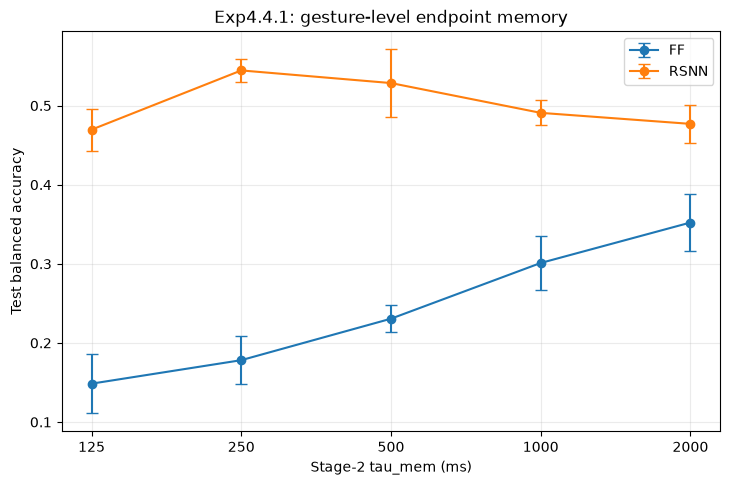

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for model in ["ff", "rsnn"]:
    sub = summary[summary["model_kind"] == model].sort_values("tau_mem_ms")
    ax.errorbar(sub["tau_mem_ms"], sub["uend_linear_ba_mean"], yerr=sub["uend_linear_ba_std"], marker="o", capsize=4, label=model.upper())
ax.set_xscale("log", base=2)
ax.set_xticks([125, 250, 500, 1000, 2000])
ax.set_xticklabels(["125", "250", "500", "1000", "2000"])
ax.set_xlabel("Stage-2 tau_mem (ms)")
ax.set_ylabel("Test balanced accuracy")
ax.set_title("Exp4.4.1: gesture-level endpoint memory")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## Readout matrix across tau


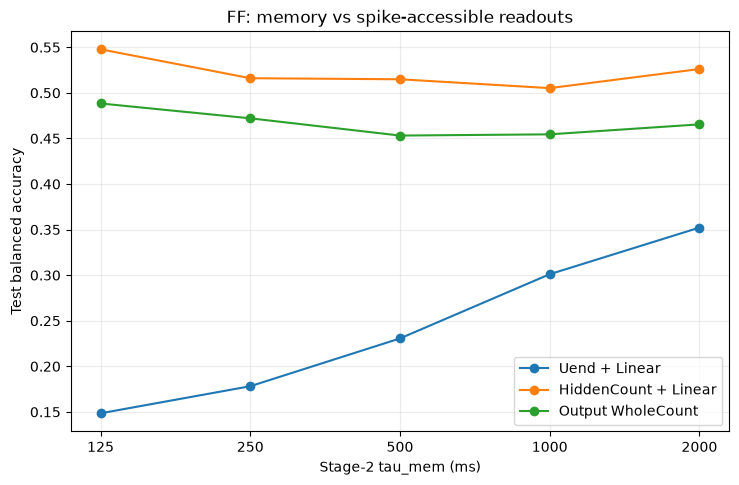

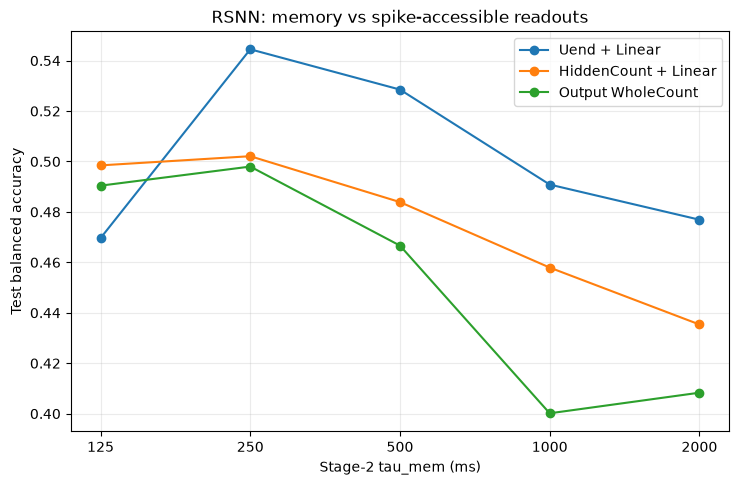

In [5]:
readouts = [("uend_linear_ba_mean", "Uend + Linear"), ("hidden_whole_count_linear_ba_mean", "HiddenCount + Linear"), ("output_whole_count_ba_mean", "Output WholeCount")]
for model in ["ff", "rsnn"]:
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    sub = summary[summary["model_kind"] == model].sort_values("tau_mem_ms")
    for col, label in readouts:
        ax.plot(sub["tau_mem_ms"], sub[col], marker="o", label=label)
    ax.set_xscale("log", base=2)
    ax.set_xticks([125, 250, 500, 1000, 2000])
    ax.set_xticklabels(["125", "250", "500", "1000", "2000"])
    ax.set_xlabel("Stage-2 tau_mem (ms)")
    ax.set_ylabel("Test balanced accuracy")
    ax.set_title(f"{model.upper()}: memory vs spike-accessible readouts")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.show()


## State-to-spike / output information gaps


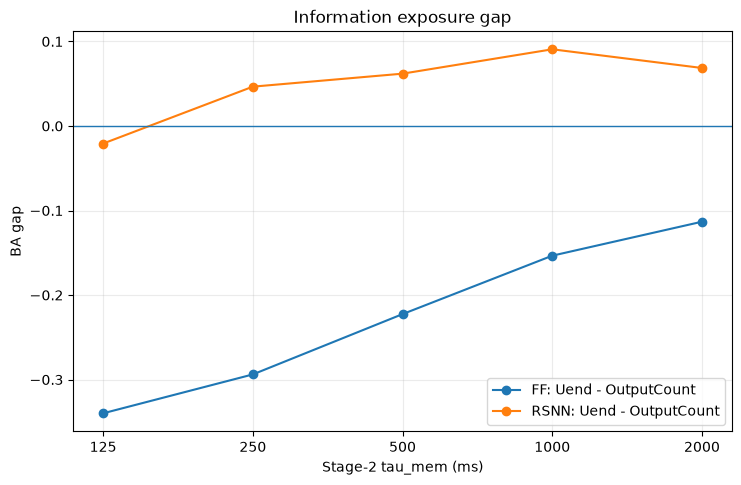

,model_kind,tau_mem_ms,uend_minus_hidden_count_ba_mean,uend_minus_hidden_count_ba_std,uend_minus_output_count_ba_mean,uend_minus_output_count_ba_std
0,ff,125,-0.399296,0.031255,-0.339862,0.065344
1,ff,250,-0.337869,0.045604,-0.293877,0.035182
2,ff,500,-0.284291,0.026900,-0.222544,0.018851
3,ff,1000,-0.204138,0.025371,-0.153433,0.036437
4,ff,2000,-0.173956,0.054961,-0.113247,0.033699
5,rsnn,125,-0.028842,0.048914,-0.020800,0.020316
6,rsnn,250,0.042394,0.035307,0.046505,0.059334
7,rsnn,500,0.044618,0.054835,0.061878,0.069237
8,rsnn,1000,0.032916,0.048621,0.090704,0.053639
9,rsnn,2000,0.041553,0.040936,0.068603,0.036103


In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for model in ["ff", "rsnn"]:
    sub = summary[summary["model_kind"] == model].sort_values("tau_mem_ms")
    ax.plot(sub["tau_mem_ms"], sub["uend_minus_output_count_ba_mean"], marker="o", label=f"{model.upper()}: Uend - OutputCount")
ax.axhline(0.0, linewidth=1)
ax.set_xscale("log", base=2)
ax.set_xticks([125, 250, 500, 1000, 2000])
ax.set_xticklabels(["125", "250", "500", "1000", "2000"])
ax.set_xlabel("Stage-2 tau_mem (ms)")
ax.set_ylabel("BA gap")
ax.set_title("Information exposure gap")
ax.legend()
ax.grid(alpha=0.25)
plt.show()
display(summary[["model_kind", "tau_mem_ms", "uend_minus_hidden_count_ba_mean", "uend_minus_hidden_count_ba_std", "uend_minus_output_count_ba_mean", "uend_minus_output_count_ba_std"]].sort_values(["model_kind", "tau_mem_ms"]))


## Paired recurrence contribution


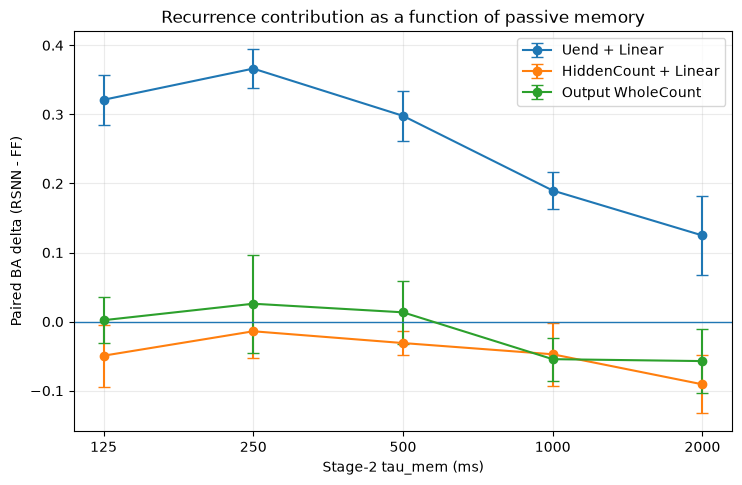

,tau_mem_ms,readout,mean,std,count
0,125,hidden_whole_count_linear,-0.049315,0.044812,5
3,250,hidden_whole_count_linear,-0.013952,0.039394,5
6,500,hidden_whole_count_linear,-0.031000,0.017979,5
9,1000,hidden_whole_count_linear,-0.047254,0.046000,5
12,2000,hidden_whole_count_linear,-0.090772,0.041922,5
1,125,output_whole_count,0.002077,0.033171,5
4,250,output_whole_count,0.025930,0.070680,5
7,500,output_whole_count,0.013486,0.045143,5
10,1000,output_whole_count,-0.054337,0.030929,5
13,2000,output_whole_count,-0.057112,0.045972,5


In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for readout, label in [("uend_linear", "Uend + Linear"), ("hidden_whole_count_linear", "HiddenCount + Linear"), ("output_whole_count", "Output WholeCount")]:
    sub = paired_summary[paired_summary["readout"] == readout].sort_values("tau_mem_ms")
    ax.errorbar(sub["tau_mem_ms"], sub["mean"], yerr=sub["std"], marker="o", capsize=4, label=label)
ax.axhline(0.0, linewidth=1)
ax.set_xscale("log", base=2)
ax.set_xticks([125, 250, 500, 1000, 2000])
ax.set_xticklabels(["125", "250", "500", "1000", "2000"])
ax.set_xlabel("Stage-2 tau_mem (ms)")
ax.set_ylabel("Paired BA delta (RSNN - FF)")
ax.set_title("Recurrence contribution as a function of passive memory")
ax.legend()
ax.grid(alpha=0.25)
plt.show()
display(paired_summary.sort_values(["readout", "tau_mem_ms"]))


## Activity / stability diagnostics


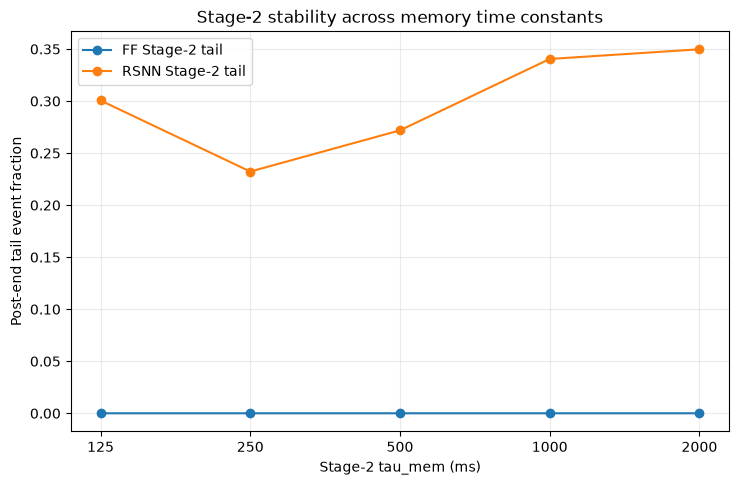

,model_kind,tau_mem_ms,state_events_per_neuron_second_mean,output_events_per_neuron_second_mean,state_tail_event_fraction_mean,output_tail_event_fraction_mean
0,ff,125,53.568035,360.130479,0.000000,0.000386
1,ff,250,57.276975,388.513959,0.000002,0.000449
2,ff,500,52.783206,354.629303,0.000002,0.000287
3,ff,1000,50.849561,338.677880,0.000006,0.000208
4,ff,2000,49.380926,342.946228,0.000009,0.000207
5,rsnn,125,36.070626,184.943693,0.300576,0.298765
6,rsnn,250,37.318184,180.471386,0.232276,0.224421
7,rsnn,500,31.241393,143.436717,0.271882,0.239233
8,rsnn,1000,40.117934,162.350923,0.340473,0.309731
9,rsnn,2000,38.750110,111.539560,0.349758,0.331344


In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for model in ["ff", "rsnn"]:
    sub = summary[summary["model_kind"] == model].sort_values("tau_mem_ms")
    ax.plot(sub["tau_mem_ms"], sub["state_tail_event_fraction_mean"], marker="o", label=f"{model.upper()} Stage-2 tail")
ax.set_xscale("log", base=2)
ax.set_xticks([125, 250, 500, 1000, 2000])
ax.set_xticklabels(["125", "250", "500", "1000", "2000"])
ax.set_xlabel("Stage-2 tau_mem (ms)")
ax.set_ylabel("Post-end tail event fraction")
ax.set_title("Stage-2 stability across memory time constants")
ax.legend()
ax.grid(alpha=0.25)
plt.show()
display(summary[["model_kind", "tau_mem_ms", "state_events_per_neuron_second_mean", "output_events_per_neuron_second_mean", "state_tail_event_fraction_mean", "output_tail_event_fraction_mean"]].sort_values(["model_kind", "tau_mem_ms"]))


## Ranking and interpretation table


In [9]:
ranking = summary.copy()
ranking["memory_rank"] = ranking["uend_linear_ba_mean"].rank(method="min", ascending=False)
ranking["deployment_rank"] = ranking["output_whole_count_ba_mean"].rank(method="min", ascending=False)
ranking = ranking.sort_values(["memory_rank", "deployment_rank"])
display(ranking[["model_kind", "tau_mem_ms", "uend_linear_ba_mean", "uend_linear_ba_std", "memory_rank", "hidden_whole_count_linear_ba_mean", "output_whole_count_ba_mean", "output_whole_count_ba_std", "deployment_rank", "uend_minus_output_count_ba_mean", "state_tail_event_fraction_mean"]])


,model_kind,tau_mem_ms,uend_linear_ba_mean,uend_linear_ba_std,memory_rank,hidden_whole_count_linear_ba_mean,output_whole_count_ba_mean,output_whole_count_ba_std,deployment_rank,uend_minus_output_count_ba_mean,state_tail_event_fraction_mean
6,rsnn,250,0.544495,0.014334,1.0,0.502100,0.497990,0.047480,1.0,0.046505,0.232276
7,rsnn,500,0.528518,0.042688,2.0,0.483900,0.466639,0.039182,5.0,0.061878,0.271882
8,rsnn,1000,0.490851,0.015948,3.0,0.457935,0.400147,0.050383,10.0,0.090704,0.340473
9,rsnn,2000,0.476920,0.024079,4.0,0.435367,0.408317,0.025632,9.0,0.068603,0.349758
5,rsnn,125,0.469620,0.026626,5.0,0.498462,0.490420,0.029090,2.0,-0.020800,0.300576
4,ff,2000,0.352182,0.036077,6.0,0.526139,0.465429,0.028278,6.0,-0.113247,0.000009
3,ff,1000,0.301051,0.034124,7.0,0.505189,0.454484,0.028748,7.0,-0.153433,0.000006
2,ff,500,0.230609,0.017028,8.0,0.514900,0.453153,0.021038,8.0,-0.222544,0.000002
1,ff,250,0.178183,0.029920,9.0,0.516052,0.472060,0.027412,4.0,-0.293877,0.000002
0,ff,125,0.148481,0.037471,10.0,0.547777,0.488343,0.036297,3.0,-0.339862,0.000000
